In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from google.colab import files

from tensorflow.keras.datasets import fashion_mnist

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

(X_train_img, y_train), (X_test_img, y_test) = fashion_mnist.load_data()

nomes_classes = {
    0: "Camiseta/Top", 1: "Calça", 2: "Suéter", 3: "Vestido",
    4: "Casaco", 5: "Sandália", 6: "Camisa", 7: "Tênis",
    8: "Bolsa", 9: "Bota"
}

X_train_img = X_train_img[:12000]
y_train = y_train[:12000]

X_test_img = X_test_img[:2000]
y_test = y_test[:2000]

X_train = X_train_img.reshape(len(X_train_img), -1) / 255.0
X_test = X_test_img.reshape(len(X_test_img), -1) / 255.0

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino: (12000, 784)
Teste: (2000, 784)


Acurácia: 0.8695
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       200
           1       0.99      0.96      0.97       203
           2       0.77      0.83      0.80       214
           3       0.85      0.86      0.85       190
           4       0.82      0.77      0.80       219
           5       0.96      0.95      0.96       195
           6       0.68      0.68      0.68       197
           7       0.93      0.95      0.94       200
           8       0.94      0.97      0.95       194
           9       0.96      0.94      0.95       188

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



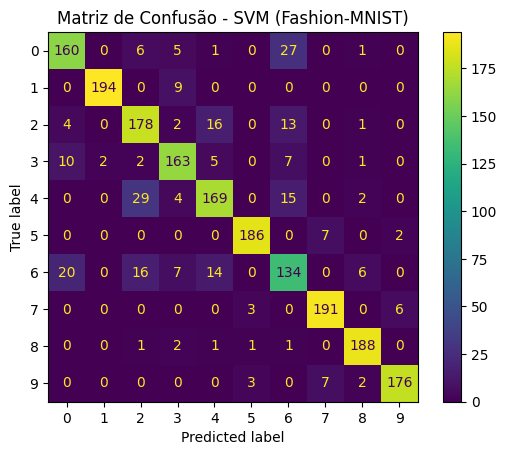

In [2]:
modelo_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
])

modelo_svm.fit(X_train, y_train)

y_pred = modelo_svm.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Gerar Matriz de Confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de Confusão - SVM (Fashion-MNIST)")
plt.show()

In [3]:
def preparar_imagem_fashion(imagem_np):
    img = imagem_np.astype(np.uint8)

    img_blur = cv2.GaussianBlur(img, (3, 3), 0)

    # Binarização: fundo -> preto / objeto -> branco
    _, thresh = cv2.threshold(
        img_blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    coords = cv2.findNonZero(thresh)

    if coords is None:
        raise ValueError("Nenhum objeto encontrado na imagem.")

    x, y, w, h = cv2.boundingRect(coords)

    objeto = thresh[y:y+h, x:x+w]

    altura, largura = objeto.shape

    if altura > largura:
        nova_altura = 20
        nova_largura = max(1, int(largura * 20 / altura))
    else:
        nova_largura = 20
        nova_altura = max(1, int(altura * 20 / largura))

    objeto_redim = cv2.resize(
        objeto,
        (nova_largura, nova_altura),
        interpolation=cv2.INTER_AREA
    )

    img_28 = np.zeros((28, 28), dtype=np.uint8)

    x_offset = (28 - nova_largura) // 2
    y_offset = (28 - nova_altura) // 2

    img_28[
        y_offset:y_offset+nova_altura,
        x_offset:x_offset+nova_largura
    ] = objeto_redim

    vetor = img_28.reshape(1, -1) / 255.0

    return vetor, img_28

Saving camisa.png to camisa.png


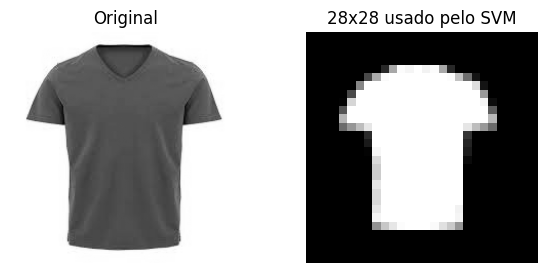

Objeto reconhecido pelo SVM: Camiseta/Top (Classe 0)


In [4]:
uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]

imagem = Image.open(nome_arquivo).convert("L")
imagem_np = np.array(imagem)

vetor, imagem_processada = preparar_imagem_fashion(imagem_np)

predicao = modelo_svm.predict(vetor)[0]
nome_predicao = nomes_classes[predicao]

plt.figure(figsize=(7, 3))

plt.subplot(1, 2, 1)
plt.imshow(imagem_np, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(imagem_processada, cmap="gray")
plt.title("28x28 usado pelo SVM")
plt.axis("off")

plt.show()

print(f"Objeto reconhecido pelo SVM: {nome_predicao} (Classe {predicao})")